# Analisi delle immagini, riscritto in grazia

## Importazione delle librerie



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
directories = [f"lampadina{i}_test" for i in [1,2,3]]

all_images = []

for dir in directories:
    data_folder = os.path.join(base_img_folder, dir)
    image_folder = os.path.join(data_folder, "images")
    images, image_timestamps = load_images_from_folder(image_folder)
    images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)
    
    all_images.append([images, image_timestamps])



In [4]:
imgs1 = all_images[0][0]
imgs2 = all_images[1][0]
imgs3 = all_images[2][0]

In [5]:
reference_imgs = [np.mean(i[:10], axis=0).astype(np.uint8) for i in [imgs1, imgs2, imgs3]]

In [6]:
diff_imgs1 = compute_difference_from_reference(imgs1, reference_imgs[0])
diff_imgs2 = compute_difference_from_reference(imgs1, reference_imgs[1])
diff_imgs3 = compute_difference_from_reference(imgs1, reference_imgs[2])


In [7]:
average_intensities1 = compute_average_intensity(diff_imgs1)
average_intensities2 = compute_average_intensity(diff_imgs2)
average_intensities3 = compute_average_intensity(diff_imgs3)


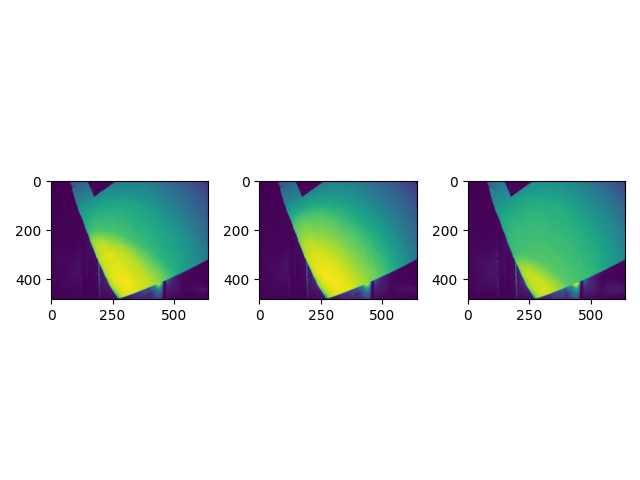

In [8]:

plt.figure()

plt.subplot(1,3,1)
plt.imshow(reference_imgs[0])

plt.subplot(1,3,2)
plt.imshow(reference_imgs[1])

plt.subplot(1,3,3)
plt.imshow(reference_imgs[2])

plt.tight_layout()
plt.show()

Deviazioni standard:
	lmpadina 1 0.0934
	lmpadina 2 0.1498

Errore percentuale:
	lmpadina 1 0.0498
	lmpadina 2 0.0293


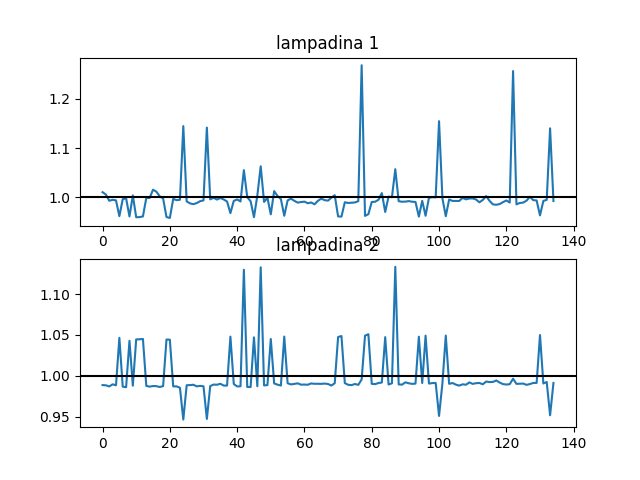

In [11]:

plt.figure()

skip = 10

plt.subplot(2, 1, 1)
mean1 = np.mean(average_intensities1[skip:])
dev1 = np.std(average_intensities1 - mean1)
plt.plot(average_intensities1[skip:] / mean1)
plt.axhline(1, color="k")
plt.title("lampadina 1")

plt.subplot(2, 1, 2)
mean2 = np.mean(average_intensities2[skip:])
dev2 = np.std(average_intensities2 - mean2)
plt.plot(average_intensities2[skip:] / mean2)
plt.axhline(1, color="k")
plt.title("lampadina 2")


print(f"Deviazioni standard:\n\tlmpadina 1 {dev1:.4f}\n\tlmpadina 2 {dev2:.4f}")
print()
print(f"Errore percentuale:\n\tlmpadina 1 {dev1/mean1:.4f}\n\tlmpadina 2 {dev2/mean2:.4f}")


plt.show()

In [13]:
print(mean1)
print(mean2)

1.875744454089506
5.1119294945987654


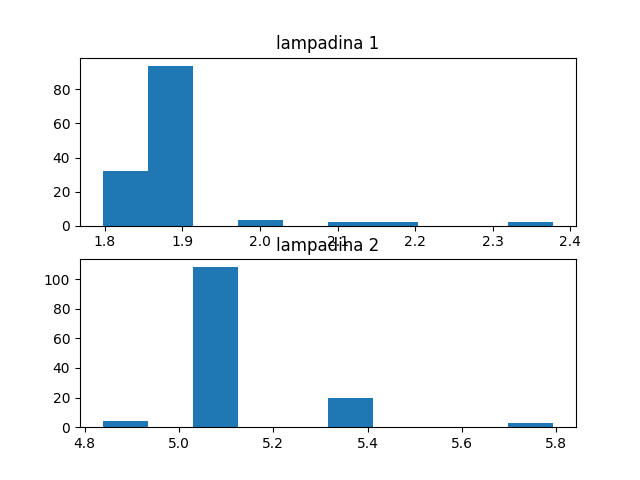

In [12]:
plt.figure()

plt.subplot(2, 1, 1)
plt.hist(average_intensities1[skip:])
plt.title("lampadina 1")

plt.subplot(2, 1, 2)
plt.hist(average_intensities2[skip:])
plt.title("lampadina 2")


plt.show()
